In [1]:
import os
import glob
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

['exp', 'obs'] ['exp', 'obs']


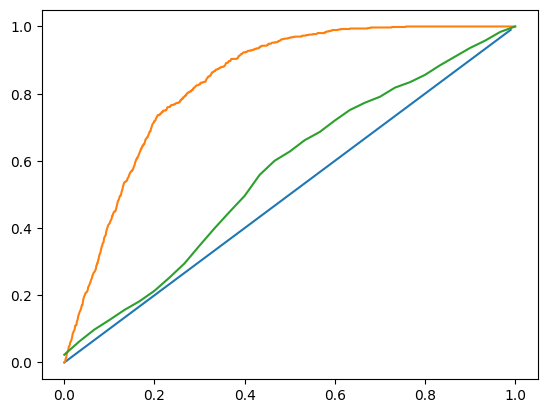

In [2]:
path = '../results/best_new/MHSDT_Dmit_SL16_B2_T5/'
before = np.load('/home/fr/Desktop/our_works/uncertainty/figures/hsstt/results/best/MHSDT_Dmit_SL16_B2_T2/exp_obs.npz')
after = np.load(os.path.join(path, 'exp_obs_re.npz'))
print(before.files, after.files)
ideal_x, ideal_y = np.arange(100) / 100, np.arange(100) / 100
before_x, before_y = before['exp'] / 100, before['obs'] / 100
after_x, after_y = after['exp'] / 100, after['obs'] / 100
plt.plot(ideal_x, ideal_y)
plt.plot(before_x, before_y)
plt.plot(after_x, after_y)



data_dict = {'ideal_x': ideal_x,
             'ideal_y': ideal_y, 
             'before_x': before_x,
             'before_y': before_y, 
             'after_x': after_x, 
             'after_y': after_y}

max_length = max(len(ideal_x), len(before_x), len(after_x))
for key in data_dict:
    data_dict[key] = np.pad(data_dict[key], (0, max_length - len(data_dict[key])), constant_values=np.nan)

data_df = pd.DataFrame.from_dict(data_dict)
data_df.to_excel(os.path.join(args.c + '.xlsx'), index=None)